In [1]:
import os
os.chdir('..')
import time
import random
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
import config
import matplotlib.pyplot as plt
from utils.geotif_io import readTiff, writeTiff
from utils.acc_pixel import acc_matrix
from utils.imgPatch import imgPatch
from model.seg_model.watnet import watnet
from utils.imgShow import imgShow,imsShow
from watnet_infer import watnet_infer

In [2]:
## --- test image --- ##
paths_s2_img = sorted(glob.glob(config.data_dir + '/*2019????.tif'))
print('image path:', paths_s2_img[0])
## --- pre-trained model --- ##
path_model = 'model/pretrained/watnet.h5'
# super parameters
patch_size = 512
overlay = 80  # the overlay area between neighboring patches
## --- result path --- ###
path_result = [os.path.splitext(path)[0] + '_water.tif' for path in paths_s2_img]
print('save path:', path_result[0])


image path: /home/yons/Desktop/developer-luo/Data/poyang-s2/sen2_20190127.tif
save path: /home/yons/Desktop/developer-luo/Data/poyang-s2/sen2_20190127_water.tif


/home/yons/Desktop/developer-luo/Data/poyang-s2/sen2_20190731.tif


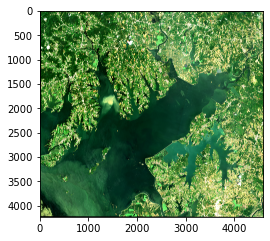

In [3]:
# -----Load and prepare the satellite image data -----#
id_img = 4
sen2_img, img_info = readTiff(path_in=paths_s2_img[id_img])
sen2_img = np.float32(np.clip(sen2_img/10000, a_min=0, a_max=1))  ## normalization
print(paths_s2_img[id_img])
plt.figure(figsize=(4,4))
imgShow(sen2_img, clip_percent=5)


In [10]:
### ---- surface water mapping by using pretrained watnet.
with tf.device('/device:GPU:0'):
    water_map = watnet_infer(rsimg=sen2_img, path_model=path_model)


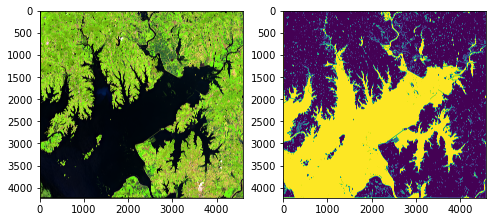

In [11]:
### show the result
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
imgShow(sen2_img, color_bands=[4,3,2])
plt.subplot(1,2,2)
imgShow(water_map)


### Save the result.

In [8]:
# # # save the result
# writeTiff(im_data=water_map.astype(np.int8), \
#           im_geotrans=img_info['geotrans'], \
#           im_geosrs=img_info['geosrs'], \
#           path_out = paths_pred[id_img])
